# Depth-Averaged Submarine Melt Deviation (PDS) Histograms

This notebook visualizes the distribution of depth-averaged percentage deviation in submarine melt (PDS) between near-glacier and fjord-mouth profiles. Positive values are instances where the depth-averaged melt rate are higher near the glacier relative to the mouth.





## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Set file paths

In [2]:
# Define file paths from config file 
from config_loader import load_paths

# Load all base paths
paths = load_paths()

csv_dir = paths["csv_dir"]
nc_dir = paths["nc_dir"]
results_root = paths["results_dir"]

# Script-specific output folder for plots
output_dir = results_root / "thermalForcing"
output_dir.mkdir(parents=True, exist_ok=True)

# Script-specific CSV file
csv_file = csv_dir / "PDS_profiles.csv"


## Set global font parameters for plots

In [3]:
# set global font size for plots
plt.rcParams.update({'font.size': 20})
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20


## Read in PDS profiles 
These profiles are created by the script "fig3_TFandPDS.ipynb". Binned 10m PDS profiles for each near-glacier and fjord mouth CTD pair. 

In [4]:
pds_df = pd.read_csv(csv_file)
pds_df.head()
print("Regions in dataset:", pds_df["region"].unique())

Regions in dataset: ['CW' 'NW' 'CE' 'SE']



## Depth-average each profile for each PDS type
This collapses the depth dimension, producing one value per glacier per \beta value (beta = 1.2 or beta = 1.6).


In [5]:
# Group by glacier (icepicks_id) and PDS_type, then take the mean across depths
depth_avg_df = (
    pds_df
    .groupby(["icepicks_id", "region", "PDS_type"])["PDS"]
    .mean()
    .reset_index()
)

# Inspect
print(depth_avg_df.head())


  icepicks_id region PDS_type        PDS
0     1(2018)     CW     high   2.587839
1     1(2018)     CW      low   1.762847
2     1(2021)     CW     high   4.059336
3     1(2021)     CW      low   2.954353
4    11(2016)     NW     high -21.011753


 ## Plot regional histograms 
 We'll create one figure with subplots, one column per region.
 - Top row: beta=1.2 
 - Bottom row: beta=1.6

 For bin width we use Freedman–Diaconis Rule (Freedman and Diaconis, 1981):

$$
w = \frac{2 \times IQR}{n^{1/3}}
$$

Where:

(w) = bin width
(IQR) = interquartile range of the dataset ((Q_3 - Q_1))
(n) = number of observations

Once the bin width (h) is known, the approximate number of bins can be calculated as:

$$
\text{Number of bins} =
\frac{\max(x) - \min(x)}{w}
$$

Source: Freedman, D. and Diaconis, P., 1981. On the histogram as a density estimator: L 2 theory. Zeitschrift für Wahrscheinlichkeitstheorie und verwandte Gebiete, 57(4), pp.453-476.

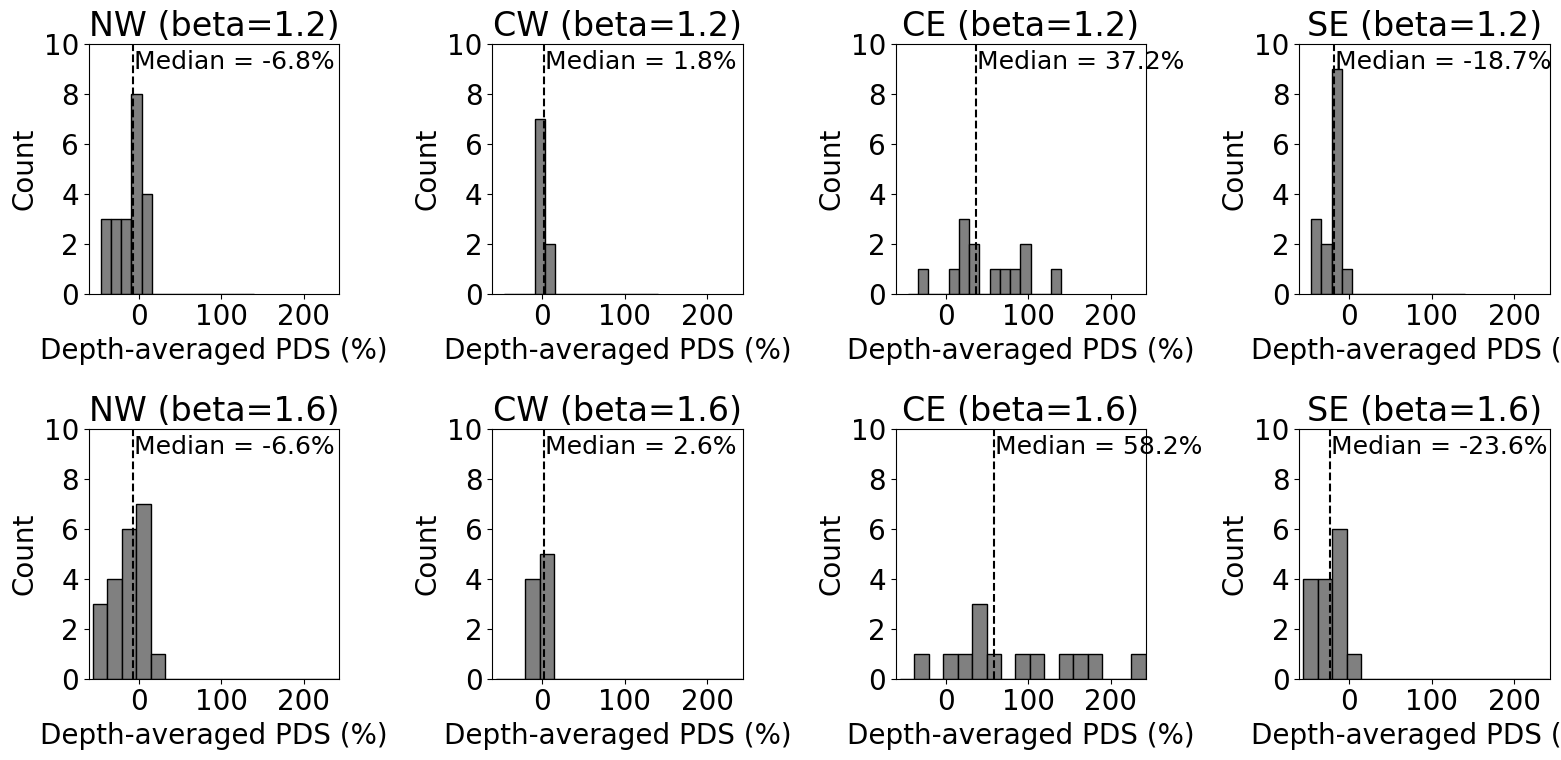

In [6]:
region_order = ["NW", "CW", "CE", "SE"]
n_regions = len(region_order)

pds_df["region"] = pd.Categorical(pds_df["region"], categories=region_order, ordered=True)
depth_avg_df["region"] = pd.Categorical(depth_avg_df["region"], categories=region_order, ordered=True)

regions = region_order

# set bin width using Freedman-Diaconis rule for each \beta group

# Separate the depth-averaged values by PDS type
all_low = depth_avg_df[depth_avg_df["PDS_type"]=="low"]["PDS"].dropna().values
all_high = depth_avg_df[depth_avg_df["PDS_type"]=="high"]["PDS"].dropna().values

# Freedman-Diaconis bin width for low
q75, q25 = np.percentile(all_low, [75 ,25])
iqr = q75 - q25
n = len(all_low)
bin_width_low = 2 * iqr / np.cbrt(n)
nbins_low = int(np.ceil((all_low.max() - all_low.min()) / bin_width_low))

# Freedman-Diaconis bin width for high
q75, q25 = np.percentile(all_high, [75 ,25])
iqr = q75 - q25
n = len(all_high)
bin_width_high = 2 * iqr / np.cbrt(n)
nbins_high = int(np.ceil((all_high.max() - all_high.min()) / bin_width_high))

# uniform bin edges across all histograms
bins_low = np.arange(all_low.min(), all_low.max() + bin_width_low, bin_width_low)
bins_high = np.arange(all_high.min(), all_high.max() + bin_width_high, bin_width_high)

xmin = min(all_low.min(), all_high.min()) - 5
xmax = max(all_low.max(), all_high.max()) + 5

fig, axes = plt.subplots(2, n_regions, figsize=(4*n_regions, 8), sharex=False, sharey=False)

for col, region in enumerate(regions):
    # Beta = 1.2 (PDS low) top row
    data_low = depth_avg_df[(depth_avg_df["region"]==region) & (depth_avg_df["PDS_type"]=="low")]["PDS"]
    axes[0, col].hist(data_low.dropna(), bins=bins_low, color="grey", edgecolor="k")
    axes[0, col].set_title(f"{region} (beta=1.2)")
    axes[0, col].set_xlabel("Depth-averaged PDS (%)")
    axes[0, col].set_ylabel("Count")
    axes[0, col].set_xlim(xmin, xmax)
    axes[0, col].set_ylim(0, 10)
    axes[0, col].set_xticks([0, 100, 200])
    axes[0, col].set_yticks(np.arange(0, 12, 2))

    # median lines
    median_regional_low = np.median(data_low.dropna())
    axes[0, col].axvline(x=median_regional_low, color='k', linestyle='--', label=f'Median = {median_regional_low:.1f}%')
    
    #text label
    axes[0, col].text(
    median_regional_low + 1,
    axes[0, col].get_ylim()[1] * 0.9,
    f"Median = {median_regional_low:.1f}%",
    fontsize=18,)
    
    # Beta = 1.6 (PDS high) bottom row
    data_high = depth_avg_df[(depth_avg_df["region"]==region) & (depth_avg_df["PDS_type"]=="high")]["PDS"]
    axes[1, col].hist(data_high.dropna(), bins=bins_high, color="grey", edgecolor="k")
    axes[1, col].set_title(f"{region} (beta=1.6)")
    axes[1, col].set_xlabel("Depth-averaged PDS (%)")
    axes[1, col].set_ylabel("Count")
    axes[1, col].set_xlim(xmin, xmax)
    axes[1, col].set_xticks([0, 100, 200])
    axes[1, col].set_ylim(0, 10)
    axes[1, col].set_yticks(np.arange(0, 12, 2))

    # median lines
    median_regional_high = np.median(data_high.dropna())
    axes[1, col].axvline(x=median_regional_high, color='k', linestyle='--', label=f'Median = {median_regional_high:.1f}%')
    
    #text label
    axes[1, col].text(
    median_regional_high + 1,
    axes[1, col].get_ylim()[1] * 0.9,
    f"Median = {median_regional_high:.1f}%",
    fontsize=18,)
    


plt.tight_layout()
plt.show()
plt.close()

## Single histogram of all profiles, separate for PDS low and high

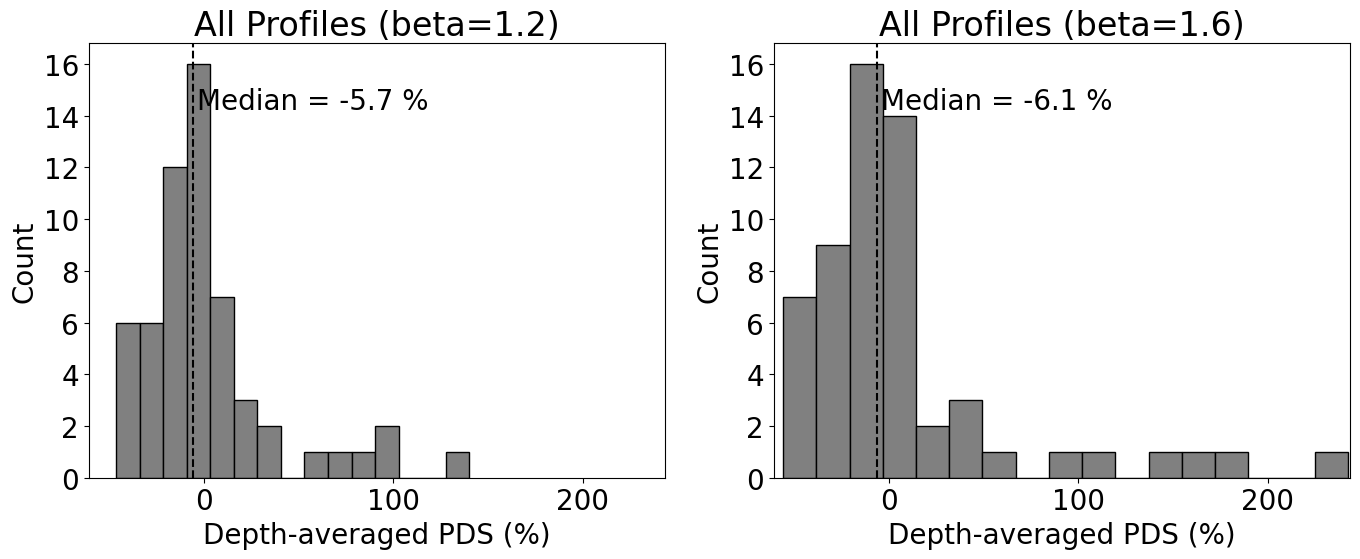

In [7]:

# Plot the two histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=False)

axes[0].hist(all_low, bins=bins_low, color="grey", edgecolor="k")
axes[0].set_title("All Profiles (beta=1.2)")
axes[0].set_xlabel("Depth-averaged PDS (%)")
axes[0].set_yticks(np.arange(0, 18, 2))
axes[0].set_ylabel("Count")

axes[1].hist(all_high, bins=bins_high, color="grey", edgecolor="k")
axes[1].set_title("All Profiles (beta=1.6)")
axes[1].set_xlabel("Depth-averaged PDS (%)")
axes[1].set_ylabel("Count")
axes[1].set_yticks(np.arange(0, 18, 2))

axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)

#median line
median_low = np.median(all_low)
median_high = np.median(all_high)
axes[0].axvline(x=median_low, color='k', linestyle='--', label="Median")
axes[1].axvline(x=median_high, color='k', linestyle='--', label="Median")

# label median values
axes[0].text(median_low + 2.0, 0.9 * axes[0].get_ylim()[1], f"Median = {median_low:.1f} %", fontsize=20, va='top')
axes[1].text(median_high + 2.0, 0.9 *axes[1].get_ylim()[1], f"Median = {median_high:.1f} %", fontsize=20, va='top')


plt.tight_layout()
plt.show()
plt.close()